# Memristor with AI

## Import and Formatting

The goal of this section is to import all the necessary files and libraries required for the subsequent data analysis.  
It also includes setting up the formatting parameters for the plots and visualizations.

### Import

In [18]:
# ----  Standard import
import matplotlib.pyplot as plt
import numpy as np

# ----- Spice import
from PySpice.Spice.Netlist import Circuit, SubCircuit, SubCircuitFactory
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Unit import *

### Formatting

Adjusting Plotly chart settings for clarity and consistency.

In [19]:
# ----  Formatting charts
%matplotlib inline
from IPython.core.pylabtools import figsize
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.edgecolor']  = "#bcbcbc"
mpl.rcParams['patch.linewidth'] = 0.5
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['axes.facecolor']  = "#eeeeee"
mpl.rcParams['axes.labelsize']  = "large"
mpl.rcParams['axes.grid']       = True
mpl.rcParams['grid.linestyle']  = "--"
mpl.rcParams['patch.edgecolor'] = "#eeeeee"
mpl.rcParams['axes.titlesize']  = "x-large"

## Introduction

Ce notebook reprendre le travail est les code de *jurjsorinliviu*, il est possible de retrouver tous les codes orginaux sont présent sur son github à l'addresse suivant : https://github.com/jurjsorinliviu/In-Situ-Memristive-Learning-Method-for-Pattern-Classification/tree/main

Dans ce premier code, l'objectif est d'étudier les données qui vont être étudier.

## Dataset

L'objectif dans un premier temps est de comprendre comment fonctionne les réseau de neuronne, donc les données qui vont être utilisé sont très simple. Ce sont juste des données de classification, ou l'objectif est de savoir si cela correspend à un signe `X`, à un signe `+` ou un signe `U` ou pour finir à un signe `=`. Les images sont des matrices 3 sur 3 fois qui sont soit 1 ou 0. La [](#XPUE_data_visualisation) permet de représenter les données. Il est possible de noté que chaque pixel est utilisé de manière relativement identique entre deux ou trois fois comme cela est montré sur le [](#XPUE_data_memristor_table).

```{figure} images/XPUE_data.svg
:name: XPUE_data_visualisation
:align: center
:width: 700px

Données qui permettre de visualiser les données
```

```{table} Visualisation des pixels activé ou non suivant le cas de figures
:name: XPUE_data_memristor_table
:align: center


| col | row | X | + | U | = | total |
|:---:|:---:|:-:|:-:|:-:|:-:|:-----:|
|  0  |  0  | 1 | 0 | 1 | 1 | 3
|  0  |  1  | 0 | 1 | 1 | 0 | 2
|  0  |  2  | 1 | 0 | 1 | 1 | 3
|  1  |  0  | 0 | 1 | 0 | 1 | 2
|  1  |  1  | 1 | 1 | 0 | 0 | 2
|  1  |  2  | 0 | 1 | 1 | 1 | 3
|  2  |  0  | 1 | 0 | 1 | 1 | 3
|  2  |  1  | 0 | 1 | 1 | 0 | 2
|  2  |  2  | 1 | 0 | 1 | 1 | 3
|  **TOTAL** |   | 5 | 5 | 7 | 6 | 23
```


In [49]:
def plotXPUEImages(data_X):
    """Plot the images of the XPUE dataset."""
    
    shapes_names = ['X', '+', 'U', '=']

    # plot them all in a single image, without the titles or axes
    fig, axs = plt.subplots(1,len(shapes_names))
    
    for i in range(len(data_X)):
        axs[i].imshow(np.array(data_X[i]).reshape(3, 3), cmap='gray')
        axs[i].axis('off')
        
        # add name of the shape
        axs[i].text(0.8, -1, shapes_names[i], fontsize=12, color='white')
    
    plt.subplots_adjust(wspace=0.2)
    plt.suptitle('XPUE 3x3 images', fontsize=16, color='white')
    fig.patch.set_facecolor('black')
    
    plt.show()

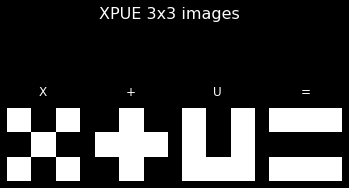

In [50]:
data_X = [
    [1, 0, 1, 0, 1, 0, 1, 0, 1], # X shape
    [0, 1, 0, 1, 1, 1, 0, 1, 0], # + shape
    [1, 0, 1, 1, 0, 1, 1, 1, 1], # U shape
    [1, 1, 1, 0, 0, 0, 1, 1, 1], # = shape
]
plotXPUEImages(data_X)

In [24]:
class Memristor(SubCircuit):
    '''
    Link of the program : https://github.com/jurjsorinliviu/In-Situ-Memristive-Learning-Method-for-Pattern-Classification/blob/main/memristor.py
    '''
    def __init__(self, name, K=0.00005, Kp=0.13*10**-3, 
                 C=0.1@u_pF, Vto=0, 
                 SwitchRoff=10**20, SwitchRon=10**-3):
        __nodes__ = ('S', 'D', 'phi')
        
        self.cmem = 'Cmem'
        self.o    = 'o'
        
        SubCircuit.__init__(self, name, *__nodes__)
        # self.parameters = {'K': K, 'Kp': Kp, 'C': C, 'Vto': Vto}
        
        self.VCCS('g', self.gnd, self.o, 'D', 'S', K)
        self.R(1, 'o', self.gnd, 1e12)
        self.VoltageControlledSwitch(
            'sw', self.o, self.cmem, 'phi', 
            self.gnd, model='my_switch')
        self.model(
            'my_switch', "SW", 
            aRon=SwitchRon, Roff=SwitchRoff, Vt=0.5)
        self.C(1, self.gnd, self.cmem, C)
        
        # M1 drain gate source body
        self.model('my_nmos', 'NMOS', level=3, Vto=Vto, Kp=Kp)
        self.MOSFET('m', 'D', self.cmem, 'S', self.gnd, model='my_nmos');

In [21]:
def get_all_nodes_Cmem(circuit):
    # this only works for the first level of subcircuits
    nodes = []
    for subcircuit in circuit.subcircuits:
        for node in subcircuit.nodes:
            if node.name.lower() == 'cmem':
                nodes.append(("X"+subcircuit.name+"."+node.name).lower())
    return nodes

def get_all_nodes_recursive(circuit, currentName):
    nodes = []
    for subcircuit in circuit.subcircuits:
        if currentName == "":
            subcircuitName = "X" + subcircuit.name
        else:
            subcircuitName = currentName + ".X" + subcircuit.name
        for node in subcircuit.nodes:
            if node.name != circuit.gnd:
                nodes.append(subcircuitName + "." + node.name)
        nodes += get_all_nodes_recursive(subcircuit, subcircuitName)
    return nodes

def get_all_cmem_nodes_recursive(circuit):
    all_nodes = get_all_nodes_recursive(circuit, "")
    cmem_nodes = []
    for node in all_nodes:
        if node.lower().find("cmem") != -1:
            cmem_nodes.append(node)
    return cmem_nodes

def add_initial_condition(simulator, circuit):
    kwargDict = {}
    IC = 0
    for n in get_all_cmem_nodes_recursive(circuit):
        kwargDict[n] = IC
    print(kwargDict)
    simulator.initial_condition(**kwargDict)


class Memristor(SubCircuit):
    def __init__(self, name, K=0.00005, Kp=0.13*10**-3, C=0.1@u_pF, Vto=0, SwitchRoff=10**20, SwitchRon=10**-3):
        __nodes__ = ('S', 'D', 'phi')
        SubCircuit.__init__(self, name, *__nodes__)
        # self.parameters = {'K': K, 'Kp': Kp, 'C': C, 'Vto': Vto}
        self.VCCS('m', self.gnd, 'o', 'D', 'S', K)
        self.R('R2', 'o', self.gnd, 10**12)
        self.VoltageControlledSwitch('sw', 'o', 'Cmem', 'phi', self.gnd, model='my_switch')
        self.model('my_switch', "SW", Ron=SwitchRon, Roff=SwitchRoff, Vt=0.5)
        self.C('C', self.gnd, 'Cmem', C)
        self.model('my_nmos', 'NMOS', level=3, Vto=Vto, Kp=Kp)
        # M1 drain gate source body
        self.MOSFET(1, 'D', 'Cmem', 'S', self.gnd, model='my_nmos')

class MemristorsInSeries(SubCircuit):
    def __init__(self, name, K=0.00045, Kp=0.13*10**-3, C=0.1@u_pF, Vto=0, N=3):
        __nodes__ = ('S', 'D')
        SubCircuit.__init__(self, name, *__nodes__)
        # self.parameters = {'K': K, 'Kp': Kp, 'C': C, 'Vto': Vto}
        self.subcircuit(Memristor('Mem0', K=K, Kp=Kp, C=C, Vto=Vto))
        self.X('Mem0', 'mem0', 'S', 'o0')
        for i in range(1, N):
            self.subcircuit(Memristor('Mem'+str(i), K=K, Kp=Kp, C=C, Vto=Vto))
            self.X('Mem'+str(i), 'mem'+str(i), 'o'+str(i-1), 'o'+str(i))
        self.subcircuit(Memristor('Mem'+str(N), K=K, Kp=Kp, C=C, Vto=Vto))
        self.X('Mem'+str(N), 'mem'+str(N), 'o'+str(N-1), 'D')

def testMemristorInSeries():
    # memristors in series test
    vs = 0
    vd = 0.2
    circuit = Circuit('NMOS Transistor')
    circuit.V('S', 'S', circuit.gnd, vs@u_V)
    circuit.SinusoidalVoltageSource('D', 'D', circuit.gnd, amplitude=vd@u_V, frequency=1@u_kHz)
    circuit.subcircuit(MemristorsInSeries('SMem1', K=0.00045, Kp=0.13*10**-3, C=0.1@u_pF, Vto=0, N=3))
    circuit.X('SMem1', 'smem1', 'S', 'D')

    print(circuit)

    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    add_initial_condition(simulator, circuit)
    # kwargDict = {}
    # IC = 0
    # for n in get_all_cmem_nodes_recursive(circuit):
    #     kwargDict[n] = IC
    # print(kwargDict)
    # simulator.initial_condition(**kwargDict)
    analysis = simulator.transient(step_time=0.0001@u_ms, end_time=10@u_ms)

    # plot drain current at vd
    plt.plot(np.array(analysis.branches['vd']), label='Id')
    plt.legend()
    plt.show()

    # vd vs ID
    vds = np.array(analysis['D']) - np.array(analysis['S'])

    figure, ax = plt.subplots(figsize=(20, 10))
    plt.plot(vds, -np.array(analysis.branches['vd']), label='ID')
    plt.legend()

    plt.show()    

{'XMem1.Cmem': 0}


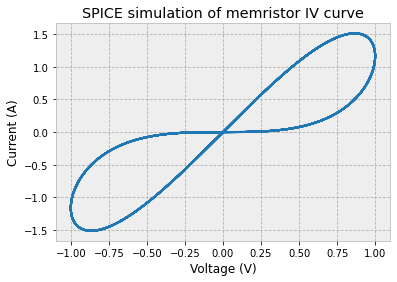

In [22]:
vs = 0
vd = 1
phi = 1.2
circuit = Circuit('NMOS Transistor')
circuit.V('S', 'S', circuit.gnd, vs@u_V)
circuit.SinusoidalVoltageSource('D', 'D', circuit.gnd, amplitude=vd@u_V, frequency=1@u_kHz, offset=0@u_V)
circuit.subcircuit(Memristor('Mem1', K=0.0002, Kp=0.13*10**-3, C=0.1@u_pF, Vto=0))
circuit.V('phi', 'phi', circuit.gnd, phi@u_V)
circuit.X('Mem1', 'mem1', 'S', 'D', 'phi')

simulator = circuit.simulator(temperature=25, nominal_temperature=25)
# IMPORTANT! the initial condition is neccesary for capacitor to work
add_initial_condition(simulator, circuit)

analysis = simulator.transient(step_time=0.0001@u_ms, end_time=10@u_ms, use_initial_condition=True)

# vd vs ID
vds = np.array(analysis['D']) - np.array(analysis['S'])
plt.plot(vds, np.array(analysis.branches['vs']))
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.title("SPICE simulation of memristor IV curve")
plt.savefig('memristor_circuit_simulation.png')
plt.show()

In [26]:
class SchmittTrigger(SubCircuit):
    def __init__(self, name, maxVoltage=1@u_V, threshold=0.5@u_V, vcc_offset=0, vcc_n_offset=0):
        __nodes__ = ('vin', 'vout2')
        SubCircuit.__init__(self, name, *__nodes__)
        self.R(1, 1, self.gnd, 100@u_Ω)
        self.R(2, 'vout', 1, 100@u_Ω)
        self.V('+vcc', '+Vcc', self.gnd, maxVoltage+vcc_offset@u_V)
        self.V('-vcc', '-Vcc', self.gnd, vcc_n_offset@u_V)
        # circuit.V('vb', 'vb', circuit.gnd, 0@u_V)
        self.X(f'op_amp', 'uopamp_lvl2', 'vin', self.gnd, f'+Vcc', '-Vcc', 'vout', Ilimit=100@u_MA, Vos=-threshold, Vmax=1@u_MV, Iq=1@u_MA, GBW=10**10@u_Hz, Rout=1@u_Ω, Avol=10**5)
        
        self.V('+vcc2', '+Vcc2', self.gnd, maxVoltage+vcc_offset@u_V)
        self.V('-vcc2', '-Vcc2', self.gnd, vcc_n_offset@u_V)
        self.X(f'op_amp2', 'uopamp_lvl2', 'vout', self.gnd, f'+Vcc2', '-Vcc2', 'vout2', Ilimit=100@u_MA, Vos=-maxVoltage/2, Vmax=1@u_MV, Iq=1@u_MA, GBW=10**10@u_Hz, Rout=1@u_Ω, Avol=10**5)
        # V = +- 0.63*Vcc
        # self.R('load', 2, self.gnd, 100@u_Ω)

if __name__ == "__main__":
    circuit = Circuit('Layer Connections')
    # libraries_path = find_libraries()
    # spice_library = SpiceLibrary(libraries_path)
    # circuit.include(spice_library['2n2222a'])
    # circuit.include('2n2222a.lib')
    circuit.include("uopamp_v1.1.lib")

    # circuit.V(1, 1, circuit.gnd, 1@u_V)

    # circuit.R("schmitt", 'sch_1', 1, 200@u_kΩ)
    # circuit.R("schmitt2", 2, 'sch_1', 10@u_kΩ)
    # circuit.V('+vcc', '+Vcc', circuit.gnd, 1@u_V)
    # # -vcc voltage
    # circuit.V('-vcc', '-Vcc', circuit.gnd, -1@u_V)
    # circuit.X(f'op_amp', 'uopamp_lvl2', "sch_1", circuit.gnd, f'+Vcc', '-Vcc', 2)
    # # load
    # circuit.R('load', 2, circuit.gnd, 1@u_kΩ)
    voltages = []
    vals = np.arange(-1, 2, 0.01)
    for val in vals:
        circuit = Circuit('Layer Connections')
        libraries_path = find_libraries()
        spice_library = SpiceLibrary(libraries_path)
        # circuit.include(spice_library['2n2222a'])
        # circuit.include('2n2222a.lib')
        circuit.include("uopamp_v1.1.lib")
        circuit.subcircuit(SchmittTrigger('sch1', maxVoltage=1))
        circuit.V(1, 'oin', circuit.gnd, val@u_V)
        circuit.X(1, 'sch1', 'oin', 2)
        # circuit.R(1, 1, circuit.gnd, 100@u_Ω)
        # circuit.R(2, 2, 1, 100@u_Ω)
        # circuit.V('+vcc', '+Vcc', circuit.gnd, 2@u_V)
        # circuit.V('-vcc', '-Vcc', circuit.gnd, -0.0717256@u_V)
        # # circuit.V('vb', 'vb', circuit.gnd, 0@u_V)
        # circuit.X(f'op_amp', 'uopamp_lvl2', 'oin', circuit.gnd, f'+Vcc', '-Vcc', 2, Ilimit=100@u_MA, Vos=-0.5@u_V, Vmax=1@u_MV, Iq=1@u_MA, GBW=10**10@u_Hz, Rout=1@u_Ω, Avol=10**5)
        # # V = +- 0.63*Vcc
        circuit.R('load', 2, circuit.gnd, 100@u_Ω)

        # fer implementation
        # circuit.V(1, 'oin', circuit.gnd, val@u_V)
        # circuit.V('+Vcc', '+Vcc', circuit.gnd, 10@u_V)
        # circuit.V('-Vcc', '-Vcc', circuit.gnd, -10@u_V)
        # circuit.X(f'op_amp', 'uopamp_lvl2', 2, 'oin', '+Vcc', '-Vcc', 1, Ilimit=100@u_MA, Vos=0@u_V, Vmax=1@u_MV, Iq=1@u_A, GBW=10**10@u_Hz, Rout=1@u_Ω, Avol=10**5)
        # circuit.R(1, 1, 2, 100@u_Ω)
        # circuit.R(2, 2, circuit.gnd, 100@u_Ω)
        # circuit.R('load', 1, circuit.gnd, 100@u_Ω)
        print(circuit)

        simulator = circuit.simulator(temperature=25, nominal_temperature=25)
        startValue = -1
        endValue = 10
        stepValue = 0.1
        # analysis = simulator.dc(V1=slice(startValue, endValue, stepValue))
        # tran analysis
        analysis = simulator.transient(step_time=1@u_ms, end_time=5@u_ms)
        # voltages.append(np.array(analysis.nodes['2'])[-1])

        # plot voltage at node 2
        # map res to a color between red and blue
        # color = (res - 100) / (10000 - 1)
        # plt.plot(np.arange(startValue, endValue+stepValue, stepValue), np.array(analysis.nodes['2']))
        voltages.append(np.array(analysis.nodes['2'][-1]))
    plt.plot(vals, voltages)
    # draw a dotted line at y = 0
    plt.axhline(y=0, color='k', linestyle='--')
    # draw a dotted line at y = 1
    plt.axhline(y=1, color='k', linestyle='--')
    plt.show()

Error: Could not find include file C:\Users\sacha\Desktop\Python\Electronique\electronique_book\Memristor\uopamp_v1.1.lib


.title Layer Connections
.include C:\Users\sacha\Desktop\Python\Electronique\electronique_book\Memristor\uopamp_v1.1.lib
.subckt sch1 vin vout2
R1 1 0 100Ohm
R2 vout 1 100Ohm
V+vcc +Vcc 0 1.0
V-vcc -Vcc 0 0V
Xop_amp vin 0 +Vcc -Vcc vout uopamp_lvl2 Avol=100000 GBW=10000000000Hz Ilimit=100MegA Iq=1MegA Rout=1Ohm Vmax=1MegV Vos=-0.5V
V+vcc2 +Vcc2 0 1.0
V-vcc2 -Vcc2 0 0V
Xop_amp2 vout 0 +Vcc2 -Vcc2 vout2 uopamp_lvl2 Avol=100000 GBW=10000000000Hz Ilimit=100MegA Iq=1MegA Rout=1Ohm Vmax=1MegV Vos=-0.5
.ends sch1
V1 oin 0 -1.0V
X1 oin 2 sch1
Rload 2 0 100Ohm



KeyError: '2'

In [ ]:
class MemristorCrossbar(SubCircuit):
    def __init__(self, name, num_inputs=None, num_outputs=None, resistancesP=None, resistancesN=None, biasP=None, biasN=None):
        # assert name is string, num_inputs and num_outputs are integers, resistancesP and resistancesN are numpy arrays of size num_inputs x num_outputs and biasR is a numpy array of size num_outputs
        assert isinstance(name, str), 'name must be a string'
        assert isinstance(num_inputs, int), 'num_inputs must be an integer'
        assert isinstance(num_outputs, int), 'num_outputs must be an integer'
        assert isinstance(resistancesP, np.ndarray), 'resistancesP must be a numpy array'
        assert isinstance(resistancesN, np.ndarray), 'resistancesN must be a numpy array'
        assert isinstance(biasP, np.ndarray), 'biasR must be a numpy array'
        assert isinstance(biasN, np.ndarray), 'biasR must be a numpy array'
        assert resistancesP.shape == (num_inputs, num_outputs), f'resistancesP must be a numpy array of size {num_inputs} x {num_outputs} (num_inputs x num_outputs), not {resistancesP.shape}'
        assert resistancesN.shape == (num_inputs, num_outputs), f'resistancesN must be a numpy array of size {num_inputs} x {num_outputs} (num_inputs x num_outputs), not {resistancesN.shape}'
        assert biasP.shape == (num_outputs,), f'biasR must be a numpy array of size {num_outputs} (num_outputs), not {biasP.shape}'
        assert biasN.shape == (num_outputs,), f'biasR must be a numpy array of size {num_outputs} (num_outputs), not {biasN.shape}'
        # assert all values are positive
        assert np.all(resistancesP >= 0), 'resistancesP must be positive'
        assert np.all(resistancesN >= 0), 'resistancesN must be positive'

        # print(name)
        # print("Weights:")
        # print(resistancesP)
        # print()
        # print(resistancesN)
        # print()
        # print("Biases:")
        # print(biasP)
        # print()
        # print(biasN)
        inputNodesNames = [f'input_{i}' for i in range(num_inputs)]
        outputNodesNames = [f'y_{j}' for j in range(num_outputs)]
        __nodes__ = inputNodesNames + outputNodesNames
        SubCircuit.__init__(self, name, *__nodes__)

        self.V(f'bias', f'bias', self.gnd, 1@u_V)
        # Create output nodes
        output_nodes = []
        for j in range(num_outputs):
            output_node = self.get_node(f'output_p_{j}', True)
            output_nodes.append(output_node)
            output_node = self.get_node(f'output_n_{j}', True)
            output_nodes.append(output_node)

        # Create memristor crossbar connections for positive weights
        for i in range(num_inputs):
            for j in range(num_outputs):
                # Use resistors to model memristors
                resistance = resistancesP[i, j]@u_kΩ
                res = self.R(f'Rp_{i}_{j}', f'input_{i}', f'output_p_{j}', resistance)
                resistance = resistancesN[i, j]@u_kΩ
                res = self.R(f'Rn_{i}_{j}', f'input_{i}', f'output_n_{j}', resistance)

        # repeat for bias resistors
        for j in range(num_outputs):
            resistance = biasP[j]@u_kΩ
            res = self.R(f'bias_p_{j}', f'bias', f'output_p_{j}', resistance)
            resistance = biasN[j]@u_kΩ
            res = self.R(f'bias_n_{j}', f'bias', f'output_n_{j}', resistance)

        # connect the output pairs to op amps
        for j in range(num_outputs):
            # use a sigmoid neuron for each output
            self.subcircuit(LapiqueNeuron(f'neuron_{j}', 10, 0.00015, 5))
            self.X(f'neuron_{j}', f'neuron_{j}', f'output_p_{j}', f'output_n_{j}', f'y_{j}')


class SigmoidNegPosNeuron(SubCircuit):
    def __init__(self, name, vcc=20@u_V, vcc2=0.5@u_V, vcc2_offset=0@u_V, res=1@u_mΩ, rf=1@u_kΩ):
        __nodes__ = ('input+', 'input-', 'output')
        SubCircuit.__init__(self, name, *__nodes__)
        self.V(f'Vcc', f'+Vcc', self.gnd, vcc)
        self.V(f'Vcc-', f'-Vcc', self.gnd, -vcc)
        self.X(f'op_amp_p', 'uopamp_lvl2', self.gnd, f'input+', f'+Vcc', '-Vcc', f'N_j')
        self.R(f'op_amp', f'N_j', f'input+', res)
        self.R(f'op_amp2', f'N_j', f'input-', res)
        self.V(f'Vcc2', f'+Vcc2', self.gnd, vcc2+vcc2_offset)
        self.V(f'Vcc2-', f'-Vcc2', self.gnd, -vcc2+vcc2_offset)
        self.X(f'op_amp_n', 'uopamp_lvl2', self.gnd, f'input-', f'+Vcc2', '-Vcc2', f'output')
        self.R(f'_f', f'output', f'input-', rf)

class LapiqueNeuron(SubCircuit):
    def __init__(self, name, R, C, threshold):
        SubCircuit.__init__(self, name, 'in_p', 'in_n', 'out')
        # add resistances of 1k to the inputs
        # self.R('1', 'in_p', 'in_p_', 1@u_kΩ)
        # self.R('2', 'in_n', 'in_n_', 1@u_kΩ)
        # substract the two inputs
        self.subcircuit(SigmoidNegPosNeuron('sigmoid', vcc=20@u_V, vcc2=20@u_V, vcc2_offset=0.5@u_V, res=1@u_kΩ, rf=1@u_kΩ))
        self.X('sigmoid', 'sigmoid', 'in_p', 'in_n', '1')
        # self.X('sigmoid', 'sigmoid', 'in_p_', 'in_n_', 'out')

        # convert to current

        # circuit.VCCS(1, 1, circuit.gnd, circuit.gnd, 'in_',  1)
        self.VCCS('VCCS', '2', self.gnd, self.gnd, '1', 1)
        # go through RC circuit
        self.R('R', '2', self.gnd, R@u_Ω)
        self.C('C', '2', self.gnd, C@u_F)
        # TODO test this last 3 components on their own to compare with real life implementation

        self.subcircuit(SchmittTrigger('sch1', maxVoltage=1@u_V, threshold=threshold@u_V, vcc_offset=0.07, vcc_n_offset=-0.07))
        self.X(1, 'sch1', '2', 'out')

def sigmoidTest():
    # test sigmoid neuron with 0 voltage in_n and dc voltage in_p
    circuit = Circuit('Sigmoid Neuron')
    circuit.include("uopamp_v1.1.lib")
    circuit.V('input', 'in_p', circuit.gnd, 1@u_V)
    circuit.R('1', 'p', 'in_p', 1@u_kΩ)
    circuit.V('input_', 'in_n', circuit.gnd, 0@u_V)
    circuit.R('2', 'n', 'in_n', 1@u_kΩ)
    circuit.subcircuit(SigmoidNegPosNeuron('neuron', 20@u_V, 20@u_V, 0@u_V, 1@u_kΩ, 1@u_kΩ))
    circuit.X('1', 'neuron', 'p', 'n', 'out')
    # load
    circuit.R('load', 'out', circuit.gnd, 470@u_Ω)

    print(circuit)

    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.dc(Vinput=slice(0, 1, 0.01))

    figure, ax = plt.subplots(figsize=(20, 10))

    ax.plot(np.array(analysis['in_p']), np.array(analysis['out']), label='V1')

    plt.show()

def lapiqueTest():
    # test lapique neuron
    x_n = 10
    circuit = Circuit('Lapique Neuron')
    circuit.include("uopamp_v1.1.lib")
    circuit.V('input', 'in_p', circuit.gnd, 1@u_V)
    circuit.R('1', 'p', 'in_p', 1@u_kΩ)
    circuit.V('input_', 'in_n', circuit.gnd, x_n@u_V)
    circuit.R('2', 'n', 'in_n', 1@u_kΩ)
    circuit.subcircuit(LapiqueNeuron('neuron', 10, 0.00015, 5))
    circuit.X('1', 'neuron', 'p', 'n', 'out')
    # load
    circuit.R('load', 'out', circuit.gnd, 470@u_Ω)

    print(circuit)

    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.dc(Vinput=slice(0, 15, 0.01))

    figure, ax = plt.subplots(figsize=(20, 10))

    ax.plot(np.array(analysis['in_p']), np.array(analysis['out']), label='V1')
    # show a dotted line at y = 0 and y = 1
    plt.axhline(y=0, color='k', linestyle='--')
    plt.axhline(y=1, color='k', linestyle='--')
    # and at x=x_n+0.5
    plt.axvline(x=x_n+0.5, color='r', linestyle='--')

    plt.show()

def lapiqueConnectionTest():
    # test lapique neuron connection
    x_n = 0
    circuit = Circuit('Lapique Neuron')
    circuit.include("uopamp_v1.1.lib")
    circuit.V('input', 'in_p', circuit.gnd, 1@u_V)
    # circuit.R('1', 'p', 'in_p', 1@u_kΩ)
    circuit.V('input_', 'in_n', circuit.gnd, x_n@u_V)
    # circuit.R('2', 'n', 'in_n', 1@u_kΩ)
    circuit.subcircuit(LapiqueNeuron('neuron', 10, 0.00015, 5))
    circuit.X('1', 'neuron', 'in_p', 'in_n', 'out')
    circuit.V('input2', 'in_n2', circuit.gnd, 0.45@u_V)
    # circuit.R('12', 'n2', 'in_n2', 1@u_kΩ)
    # circuit.R('22', 'out_', 'out', 1@u_kΩ)
    circuit.subcircuit(LapiqueNeuron('neuron2', 10, 0.00015, 5))
    circuit.X('2', 'neuron2', 'out', 'in_n2', 'out2')
    # load
    circuit.R('load', 'out', circuit.gnd, 1@u_kΩ)

    print(circuit)

    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.dc(Vinput=slice(0, 3, 0.01))

    for node in analysis.nodes:
        print(node, np.array(analysis[node])[-1])

    figure, ax = plt.subplots(figsize=(20, 10))

    # ax.plot(np.array(analysis['in_p']), np.array(analysis['x1.2']), label='x1.2')
    ax.plot(np.array(analysis['in_p']), np.array(analysis['out']), label='Vinternal')
    ax.plot(np.array(analysis['in_p']), np.array(analysis['out2']), label='Vout')
    # show a dotted line at y = 0 and y = 1
    plt.axhline(y=0, color='k', linestyle='--')
    plt.axhline(y=1, color='k', linestyle='--')
    # and at x=x_n+0.5
    plt.axvline(x=x_n+0.5, color='r', linestyle='--')
    plt.legend()
    plt.show()


def generate_P_N_resistances(resistances):
    # return the positive and negative resistances, such that resistancesP-resistancesN = resistances
    num_inputs, num_outputs = resistances.shape
    conductances = 1/resistances
    conductancesP = np.zeros((num_inputs, num_outputs))
    conductancesN = np.zeros((num_inputs, num_outputs))
    for i in range(num_inputs):
        for j in range(num_outputs):
            if conductances[i, j] > 0:
                conductancesP[i, j] = conductances[i, j]
                conductancesN[i, j] = 10**-8
            elif conductances[i, j] == 0:
                conductancesP[i, j] = 10**-8
                conductancesN[i, j] = 10**-8
            else:
                conductancesN[i, j] = -conductances[i, j]
                conductancesP[i, j] = 10**-8

    # clip conductances between -100 and 100
    conductancesP = np.clip(conductancesP, -100, 100)
    conductancesN = np.clip(conductancesN, -100, 100)
    resistancesP = 1/conductancesP
    resistancesN = 1/conductancesN
    return resistancesP, resistancesN

def generate_P_N_bias(biasR):
    # return the positive and negative bias resistances, such that biasP-biasN = biasR
    num_outputs = len(biasR)
    biasConductances = 1/biasR
    biasConductancesP = np.zeros(num_outputs)
    biasConductancesN = np.zeros(num_outputs)
    for j in range(num_outputs):
        if biasConductances[j] > 0:
            biasConductancesP[j] = biasConductances[j]
            biasConductancesN[j] = 10**-10
        elif biasConductances[j] == 0:
            biasConductancesP[j] = 10**-10
            biasConductancesN[j] = 10**-10
        else:
            biasConductancesN[j] = -biasConductances[j]
            biasConductancesP[j] = 10**-10
    # clip conductances between -100 and 100
    biasConductancesP = np.clip(biasConductancesP, -100, 100)
    biasConductancesN = np.clip(biasConductancesN, -100, 100)

    biasResistancesP = 1/biasConductancesP
    biasResistancesN = 1/biasConductancesN
    return biasResistancesP, biasResistancesN

import json
# make model from json
class SNNModel(SubCircuit):
    def __init__(self, name_, filename, resistancesP=None, resistancesN=None, biasP=None, biasN=None, saveValues=None):
        customWeights = False
        if resistancesP is not None and resistancesN is not None and biasP is not None and biasN is not None:
            customWeights = True
        with open(filename, 'r') as f:
            data = json.load(f)["weights"]
        layers = {}
        for key in data:
            if key.startswith('fc'):
                name, t = key.split('.')
                if name not in layers:
                    layers[name] = {}
                layers[name][t] = np.array(data[key]['data'])
        layers = list(layers.values())
        self.layers = layers
        numInputs = layers[0]['weight'].shape[1]
        numOutputs = layers[-1]['weight'].shape[0]
        if customWeights:
            # assert that the custom weights have the same shape as the model
            for i in range(len(layers)):
                assert layers[i]['weight'].shape == resistancesP[i].shape, f'Custom weights for layer {i} have shape {resistancesP[i].shape}, expected {layers[i]["weight"].shape}'
                assert layers[i]['weight'].shape == resistancesN[i].shape, f'Custom weights for layer {i} have shape {resistancesN[i].shape}, expected {layers[i]["weight"].shape}'
                assert layers[i]['bias'].shape == biasP[i].shape, f'Custom bias for layer {i} have shape {biasP[i].shape}, expected {layers[i]["bias"].shape}'
                assert layers[i]['bias'].shape == biasN[i].shape, f'Custom bias for layer {i} have shape {biasN[i].shape}, expected {layers[i]["bias"].shape}'
        # print(numInputs, numOutputs)
        # create input nodes
        inputNodesNames = [f'input_{i}' for i in range(numInputs)]
        outputNodesNames = [f'output_{j}' for j in range(numOutputs)]
        __nodes__ = inputNodesNames + outputNodesNames

        if saveValues is not None:
            saveData = {}

        # print(__nodes__)
        SubCircuit.__init__(self, name_, *__nodes__)
        # create the connections between layers
        currentInputNodes = inputNodesNames.copy()
        for lnumber in range(len(layers)):
            layer = layers[lnumber]
            numLayerInputs = layer['weight'].shape[1]
            numLayerOutputs = layer['weight'].shape[0]
            if not customWeights:
                layerWeightsP, layerWeightsN = generate_P_N_resistances(1/layer['weight'])
                layerBiasP, layerBiasN = generate_P_N_bias(1/layer['bias'])
            else:
                layerWeightsP = resistancesP[lnumber]
                layerWeightsN = resistancesN[lnumber]
                layerBiasP = biasP[lnumber]
                layerBiasN = biasN[lnumber]
            if saveValues is not None:
                saveData[f'layer_{lnumber}'] = {'weightsP': layerWeightsP.tolist(), 'weightsN': layerWeightsN.tolist(), 'biasP': layerBiasP.tolist(), 'biasN': layerBiasN.tolist()}
            self.subcircuit(MemristorCrossbar(f'crossbar_{lnumber}', num_inputs=numLayerInputs, num_outputs=numLayerOutputs, resistancesP=layerWeightsP.T, resistancesN=layerWeightsN.T, biasP=layerBiasP, biasN=layerBiasN))
            layerOutputNodesNames = [f'output_{lnumber}_{j}' for j in range(numLayerOutputs)]
            if lnumber == len(layers)-1:
                # name them output nodes
                layerOutputNodesNames = outputNodesNames.copy()
            # print(currentInputNodes, layerOutputNodesNames)
            self.X(f'crossbar_{lnumber}', f'crossbar_{lnumber}', *currentInputNodes, *layerOutputNodesNames)
            currentInputNodes = layerOutputNodesNames.copy()
        if saveValues is not None:
            with open(saveValues, 'w') as f:
                json.dump(saveData, f)

if __name__ == '__main__':
    # lapiqueTest()
    # exit()
    import json
    # lapiqueConnectionTest()
    # load xor weights
    filename = 'xor_weights_snn.json'
    # filename = 'Net_model.json'
    # filename = "Net_xor.json"
    # connect inputs to the first layer
    # inputVoltages = [0, 0] # 0, 0 > 0
    # inputVoltages = [1, 0] # 1, 0 > 1
    # inputVoltages = [0, 1] # 1, 0 > 1
    # inputVoltages = [1, 1] # 1, 1 > 0
    correct = 0
    for inputVoltages in [[0, 0], [1, 0], [0, 1], [1, 1]]:
        circuit = Circuit('Xor model')
        circuit.include("uopamp_v1.1.lib")
        circuit.subcircuit(SNNModel('snn', filename))
        for i in range(len(inputVoltages)):
            circuit.V(f'input_{i}', f'input_{i}', circuit.gnd, inputVoltages[i]@u_V)
        # connect the last layer to the output
        circuit.X('snn', 'snn', 'input_0', 'input_1', 'output_0')
        # add resistance load to final output
        circuit.R(f'load', 'output_0', circuit.gnd, 1@u_kΩ)

        # print(circuit)
        
        simulator = circuit.simulator(temperature=25, nominal_temperature=25)

        analysis = simulator.transient(step_time=1@u_ms, end_time=10@u_ms)

        # print each node name
        # for node in analysis.nodes:
        #     if node.startswith('x'):
        #         pass
        #     else:
        #         print(node, np.array(analysis[node])[-1])
        # print max voltage at each output
        # print("output voltages")
        # for j in range(1):
            # print(f'max voltage at output_{j}', np.min(np.array(analysis[f'output_{j}'])))
        maxVoltage = np.max(np.array(analysis['output_0']))
        if maxVoltage > 0.5:
            if np.sum(inputVoltages) == 1:
                correct += 1
        else:
            if np.sum(inputVoltages) == 0 or np.sum(inputVoltages) == 2:
                correct += 1
    print("The circuit obtained an accuracy of", correct*100/4, "% on the test set.")

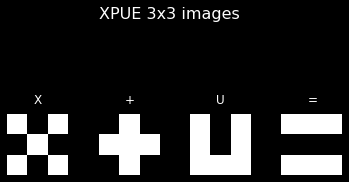

NameError: name 'LapiqueNeuron' is not defined

In [28]:
## Objectif


# Now import PySpice modules
from PySpice.Spice.NgSpice.Shared import NgSpiceShared
from scipy.linalg import solve
from PySpice.Unit import *
from PySpice.Probe.Plot import plot

from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit, SubCircuit, SubCircuitFactory

#from memristor import Memristor, add_initial_condition
#from snn_circuit import LapiqueNeuron

def saveVoltages(analysis, filename):
    """Save the voltages of the nodes at the end of the simulation in a json file."""
    with open(filename, 'w') as f:
        voltages = {}
        for node in analysis.nodes:
            voltages[node] = np.array(analysis[node])[-1]
        json.dump(voltages, f)

def loadVoltages(simulator, filename):
    """Load the voltages of the nodes for initial condition from a json file."""
    with open(filename, 'r') as f:
        voltages = json.load(f)
        # keep only the Cmem values
        for key in list(voltages.keys()):
            if 'cmem' not in key.lower():
                voltages.pop(key)
        simulator.initial_condition(**voltages)

def plotXPUEImages(data_X):
    """Plot the images of the XPUE dataset."""
    shapes_names = ['X', '+', 'U', '=']

    # plot them all in a single image, without the titles or axes
    fig, axs = plt.subplots(1,len(shapes_names))
    for i in range(len(data_X)):
        axs[i].imshow(np.array(data_X[i]).reshape(3, 3), cmap='gray')
        axs[i].axis('off')
        # add name of the shape
        axs[i].text(0.8, -1, shapes_names[i], fontsize=12, color='white')
    plt.subplots_adjust(wspace=0.5)
    plt.suptitle('XPUE 3x3 images', fontsize=16, color='white')
    # set background color to black
    fig.patch.set_facecolor('black')
    #plt.savefig('./xpue_dataset_images.png')
    plt.show()

class ShallowMemristorNetworkSubcircuit(SubCircuit):
    """A shallow memristor network subcircuit with a single layer of memristors and a single layer of Lapicque neurons."""
    def __init__(self, name, num_classes, num_inputs, K=0.000000005, Kp=0.13*10**-3, C=10**-1@u_pF):
        _inputNodes = [f'in{i}' for i in range(num_inputs)]
        _outputNodes = [f'out{i}' for i in range(num_classes)]
        # _controlNodes = [f'phi{j}_{i}' for j in range(num_classes) for i in range(num_inputs)]
        _controlNodes = [f'phi{j}' for j in range(num_classes)]
        __nodes__ = _inputNodes + _outputNodes + _controlNodes
        
        if len(__nodes__) > 1004:
            raise Exception(f'Too many nodes for the subcircuit: {len(__nodes__)}/1004')
        SubCircuit.__init__(self, name, *__nodes__)
        for j in range(num_classes):
            for i in range(num_inputs):
                self.subcircuit(Memristor(f'Memristor_P{j}_{i}', K, Kp, C, 0, 10**20, 10**-3))
                self.X(f'Memristor_P{j}_{i}', f'Memristor_P{j}_{i}', f'op_{j}', f'in{i}', f'phi{j}_{i}')
            self.subcircuit(LapiqueNeuron(f'neuron{j}', 1, 0.00015, 4))
            self.X(f'neuron{j}', f'neuron{j}', f'op_{j}', f'on{j}', f'out{j}')
            # add control nodes through 0 V voltages
            for i in range(num_inputs):
                self.V(f'phi_union{j}_{i}', f'phi{j}', f'phi{j}_{i}', 0@u_V)

def GenerateMemristorNetworkCircuit(data_X, slearn, K=0.000000005, Kp=0.13*10**-3, C=10**-1@u_pF, pulseDurations=20000, timeStep=100, periodDuration=80000):
    """Generate the circuit for the shallow memristor network."""
    num_inputs = len(data_X[0])
    num_classes = len(data_X)

    circuit = Circuit('symbol_memristor_snn')
    circuit.include("uopamp_v1.1.lib")

    phi_j_start_time = [periodDuration*i for i in range(num_classes)]

    for i in range(num_inputs):
        circuit.PulseVoltageSource(f'in_0_{i}', f'in_0_{i}', circuit.gnd, 0@u_V, data_X[0][i]@u_V, pulseDurations@u_us, 10000@u_ms, 0, 0, 0)
        for j in range(1, num_classes-1):
            circuit.PulseVoltageSource(f'in_{j}_{i}', f'in_{j}_{i}', f'in_{j-1}_{i}', 0@u_V, data_X[j][i]@u_V, pulseDurations@u_us, 10000@u_ms, j*periodDuration@u_us, 0, 0)
        circuit.PulseVoltageSource(f'in_{num_classes-1}_{i}', f'in{i}', f'in_{num_classes-2}_{i}', 0@u_V, data_X[num_classes-1][i]@u_V, pulseDurations@u_us, 10000@u_ms, (num_classes-1)*periodDuration@u_us, 0, 0)


    circuit.subcircuit(ShallowMemristorNetworkSubcircuit('snn', num_classes, num_inputs, K, Kp, C))
    nodes = [f'in{i}' for i in range(num_inputs)] + [f'out{i}' for i in range(num_classes)] + [f'phi{j}' for j in range(num_classes)]
    # print(nodes)
    circuit.X('snn', 'snn', *nodes)

    for j in range(num_classes):
        circuit.R(f'load{j}', f'out{j}', circuit.gnd, 1@u_kΩ)

        if slearn:
            # control voltages
            circuit.PulseVoltageSource(f'phi{j}', f'phi{j}', circuit.gnd, 0@u_V, 1.2@u_V, pulseDurations@u_us, 1000@u_ms, phi_j_start_time[j]@u_us, 0, 0)
        else:
            # 0 V control voltages
            circuit.V(f'phi{j}', f'phi{j}', circuit.gnd, 0@u_V)
    return circuit

    
def trainShallowMemristorNetwork(data_X, slearn, K=0.000000005, Kp=0.13*10**-3, C=10**-1@u_pF, pulseDurations=20000, timeStep=100, periodDuration=80000,datasetName='testDataset'):
    """Train the shallow memristor network on patterns data_X"""
    num_inputs = len(data_X[0])
    num_classes = len(data_X)
    inputSums = [sum(data_X[i]) for i in range(len(data_X))]
    inputsAverageSum = sum(inputSums)/len(inputSums)

    circuit = GenerateMemristorNetworkCircuit(data_X, slearn, K, Kp, C, pulseDurations, timeStep, periodDuration)
    print(circuit)
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    # load the initial conditions from json
    if not slearn:
        loadVoltages(simulator, f'{datasetName.lower()}_SNN_voltages.json')

    analysis = simulator.transient(step_time=timeStep@u_us, end_time=periodDuration*num_classes@u_us, use_initial_condition=True)

    if slearn:
        saveVoltages(analysis, f'{datasetName.lower()}_SNN_voltages.json')
        pass
    else:
        accuracy = ComputeAcuracy(data_X, num_classes, periodDuration, timeStep, analysis)
        print(f'Accuracy: {accuracy}')
        PlotConfusionMatrix(data_X, num_classes, periodDuration, timeStep, analysis, datasetName)
    if slearn:
        PlotMemristorX(analysis, num_inputs, num_classes, periodDuration, timeStep, datasetName)
        matrix = CapacitorVoltagesMatrix(analysis, num_inputs, num_classes)
        print(matrix)
        PlotInputVoltages(analysis, num_inputs, num_classes, periodDuration, datasetName)
        PlotControlVoltages(analysis, num_classes, num_inputs, datasetName)
    if not slearn:
        PlotOutputVoltages(analysis, num_classes, periodDuration, timeStep, datasetName)

def PlotConfusionMatrix(data_X, num_classes, periodDuration, timeStep, analysis, datasetName='testDataset'):
    """Plot the confusion matrix of the pattern classification."""
    confusionMatrix = ConfusionMatrix(data_X, num_classes, periodDuration, timeStep, analysis)
    plt.imshow(confusionMatrix, cmap='gray')
    plt.xticks(np.arange(num_classes))
    plt.yticks(np.arange(num_classes))
    plt.title(f'Confusion matrix of the {datasetName} classification')
    #plt.savefig(f'./{datasetName.lower()}_confusion_matrix.png')
    plt.show()

def ConfusionMatrix(data_X, num_classes, periodDuration, timeStep, analysis):
    # split the voltages of all output nodes in intervals of pulseDurations*2
    intervals = [[np.array(analysis[node])[i*periodDuration//timeStep:(i+1)*periodDuration//timeStep] for i in range(num_classes)] for node in [f'out{j}' for j in range(num_classes)]]

    # for each interval find which output node reached 0.5V first
    confusion = np.zeros((num_classes, num_classes))
    for i in range(len(intervals)):
        for k in range(len(intervals[i][0])):
            for j in range(len(intervals[i])):
                clas = False
                if intervals[j][i][k] > 0.5:
                    print(f'Image {i} classified as {j}, time: {k} us, voltage: {intervals[j][i][k]}')
                    clas = True
                    if i == j:
                        # check if no other output node reached 0.5V at the same time
                        for l in range(len(intervals[i])):
                            if l != j and intervals[l][i][k] > 0.5:
                                print(f'Image {i} classified as {l} at the same time')
                                clas = False
                                break
                        if clas:
                            confusion[i][j] += 1
                            break
            if clas:
                break
    return confusion

def ComputeAcuracy(data_X, num_classes, periodDuration, timeStep, analysis):
    # split the voltages of all output nodes in intervals of pulseDurations*2
    intervals = [[np.array(analysis[node])[i*periodDuration//timeStep:(i+1)*periodDuration//timeStep] for i in range(num_classes)] for node in [f'out{j}' for j in range(num_classes)]]

    # for each interval find which output node reached 0.5V first
    correct = 0
    for i in range(len(intervals)):
        for k in range(len(intervals[i][0])):
            for j in range(len(intervals[i])):
                clas = False
                if intervals[j][i][k] > 0.5:
                    print(f'Image {i} classified as {j}, time: {k} us, voltage: {intervals[j][i][k]}')
                    clas = True
                    if i == j:
                        # check if no other output node reached 0.5V at the same time
                        for l in range(len(intervals[i])):
                            if l != j and intervals[l][i][k] > 0.5:
                                print(f'Image {i} classified as {l} at the same time')
                                clas = False
                                break
                        if clas:
                            correct += 1
                            break
            if clas:
                break
    return correct/len(data_X)

def PlotMemristorX(analysis, num_inputs, num_classes, periodDuration, timeStep, datasetName='testDataset'):
    # plot the voltages at node cmem nodes in a single plot
    fig, axs = plt.subplots(num_inputs)
    for i in range(num_inputs):
        for j in range(num_classes):
            axs[i].plot(np.array(analysis.nodes[f'xsnn.xmemristor_p{j}_{i}.cmem']), label=f'X_{j}_{i}')
        # remove x ticks
        axs[i].set_xticks([])
        maxValue = round(max([max(np.array(analysis.nodes[f'xsnn.xmemristor_p{j}_{i}.cmem'])) for j in range(num_classes)]))
        axs[i].set_yticks([0, maxValue])
        axs[i].set_ylim(0, 1.2*maxValue)
    fig.set_size_inches(10, 10)
    fig.legend(['j=0', 'j=1', 'j=2', 'j=3'], loc='right')
    for i in range(num_inputs):
        fig.text(0.05, 0.855-(0.78/(num_inputs))*i, f'X_{i}', fontsize=10, color='black')
    # add x ticks
    _begin = 0
    _end = periodDuration*num_classes/timeStep+1
    _step = periodDuration/timeStep
    print("Begin: ", _begin, "End: ", _end, "Step: ", _step)
    plt.xticks(np.arange(_begin, _end, _step))
    plt.xlabel('Time step')
    plt.suptitle(f'Memristor capacitor voltages (X(t)) for the \'{datasetName}\' dataset')
    #plt.savefig(f'./{datasetName.lower()}_capacitor_voltages.png')
    plt.show()
    plt.clf()

def CapacitorVoltagesMatrix(analysis, num_inputs, num_classes):
    matrix = np.zeros((num_inputs, num_classes))
    for i in range(num_inputs):
        for j in range(num_classes):
            matrix[i][j] = np.array(analysis.nodes[f'xsnn.xmemristor_p{j}_{i}.cmem'])[-1]
    return matrix

def PlotInputVoltages(analysis, num_inputs, num_classes, periodDuration, datasetName='testDataset'):
    # plot the input voltages in a single figure, vertically
    fig, axs = plt.subplots(num_inputs, 1)
    for j in range(num_inputs):
        # plot with different colors
        color = plt.cm.viridis(j/num_inputs)
        axs[j].plot(np.array(analysis.nodes[f'in{j}']), label=f'V{j}', c=color)
        # remove y ticks
        axs[j].set_yticks([])
        # remove x ticks
        axs[j].set_xticks([])
        # set the y interval to 0,1
        axs[j].set_ylim(0, 1)
        axs[j].legend([f'V_{j}'], fontsize=4)
    # set the title of the plot
    fig.suptitle(f'Input data voltages for the \'{datasetName}\' dataset')
    # set plot size to be larger
    fig.set_size_inches(10, 10)
    plt.xlabel('Time step')
    plt.xticks(np.arange(0, num_classes*periodDuration/timeStep+1, pulseDuration/timeStep))
    # add texts
    for i in range(num_inputs):
        fig.text(0.05, 0.855-(0.78/(num_inputs))*i, f'V_{i}', fontsize=10, color='black')
    plt.suptitle(f'Input voltages for the \'{datasetName}\' dataset')
    #plt.savefig(f'./{datasetName.lower()}_input_voltages.png')
    plt.show()
    plt.clf()

def PlotControlVoltages(analysis, num_classes, num_inputs, datasetName='testDataset'):
    # plot the control voltages
    fig, axs = plt.subplots(num_classes, 1)

    # add plots of the phi voltages
    for j in range(num_classes):
        try:
            color = plt.cm.viridis(j/num_classes)
            axs[j].plot(np.array(analysis.nodes[f'phi{j}']), label=f'phi{j}', c=color)
            axs[j].set_yticks([])
            axs[j].legend([f'phi_{j}'], fontsize=4)
            axs[j].set_ylim(0, 1.2)
        except Exception as e:
            print(e)
            print(f'phi{j} not found')
    # set the title of the plot
    fig.suptitle(f'Control voltages for the \'{datasetName}\' dataset')
    # set plot size to be larger
    fig.set_size_inches(10, 10)
    plt.xlabel('Time step')
    plt.suptitle(f'Control voltages for the \'{datasetName}\' dataset')
    # add texts
    for i in range(num_classes):
        fig.text(0.05, 0.855-(0.78/(num_classes))*i, f'phi_i_{i}', fontsize=10, color='black')
    #plt.savefig(f'./{datasetName.lower()}_control_voltages.png')
    plt.show()
    plt.clf()

def PlotOpNodeVoltages(analysis, num_classes, num_inputs):
    # plot the op_j node voltages and then the input voltages
    fig, axs = plt.subplots(2)
    for j in range(num_classes):
        axs[0].plot(np.array(analysis.nodes[f'op_{j}']), label=f'op{j}')
    for i in range(num_inputs):
        axs[1].plot(np.array(analysis.nodes[f'in{i}']), label=f'in{i}')
    plt.legend()
    plt.show()

def PlotOutputVoltages(analysis, num_classes, periodDuration, timeStep, datasetName='testDataset'):
    # output voltages
    fig, axs = plt.subplots(num_classes, 1)
    # set the size of the figure
    fig.set_size_inches(10, 10)
    for i in range(num_classes):
        for j in range(num_classes):
            axs[i].plot(np.array(analysis.nodes[f'out{j}'][i*periodDuration//timeStep:i*periodDuration//timeStep+periodDuration//(6*timeStep)]), label=f'out{j}')
        axs[i].set_yticks([])
        # set the y interval to 0,1
        axs[i].set_ylim(0, 1)
        # axs[i].text(-29, 0.4, f'Input image {i}', fontsize=12, color='black')
    fig.suptitle(f'Output neuron voltages for the \'{datasetName}\' dataset')
    fig.legend([f"out_{j}" for j in range(num_classes)], loc='right')
    plt.xlabel('Time step')
    # add texts
    for i in range(num_classes):
        fig.text(0.05, 0.855-(0.78/(num_classes))*i, f'out_{i}', fontsize=10, color='black')
    #plt.savefig(f'./{datasetName.lower()}_output_voltages.png')
    plt.show()


def plot012345Images(data_X):
    # plot in a single plot each 3x5 image as for xpue dataset
    fig, axs = plt.subplots(1, 6)
    for i in range(6):
        axs[i].imshow(np.array(data_X[i]).reshape(5, 3), cmap='gray')
        axs[i].axis('off')
        axs[i].text(0.8, -1, str(i), fontsize=12, color='white')
    plt.subplots_adjust(wspace=0.5)
    plt.suptitle('012345 images', fontsize=16, color='white')
    # set background color to black
    fig.patch.set_facecolor('black')
    #plt.savefig('./012345_dataset_images.png')
    plt.show()

if __name__ == "__main__":
    data_X = [
        # X shape
        [1, 0, 1, 0, 1, 0, 1, 0, 1],
        # + shape
        [0, 1, 0, 1, 1, 1, 0, 1, 0],
        # U shape
        [1, 0, 1, 1, 0, 1, 1, 1, 1],
        # = shape
        [1, 1, 1, 0, 0, 0, 1, 1, 1],
    ]
    plotXPUEImages(data_X)
    
    # for xpue dataset this configuration works for both slearn and not slearn
    timeStep = 10
    pulseDuration = 5000
    periodDuration = 3*pulseDuration
    name='xpue'

    slearn = True

    trainShallowMemristorNetwork(data_X, slearn, K=0.000000005, Kp=0.13*10**-3, C=10**-1@u_pF, pulseDurations=pulseDuration, timeStep=timeStep, periodDuration=periodDuration, datasetName=name.upper())